In [1]:
import keras
import datetime
import tensorflow                       as tf
from tensorflow.keras.callbacks         import TensorBoard
from tensorflow.keras.layers            import Input, Lambda,UpSampling2D, Conv2D,Dropout,MaxPooling2D,Conv2DTranspose,concatenate,BatchNormalization, Activation,ConvLSTM2D
from tensorflow.keras.models            import Model
from tensorflow.keras.optimizers        import Adam,RMSprop,SGD
from keras.utils                        import plot_model
from tensorflow.keras                   import layers, models
from tensorflow.keras.losses            import mae
from tensorflow.keras.callbacks         import LearningRateScheduler

import sys
import os
import numpy as np
import math
import random, time
from pathlib                        import Path
from PIL                            import Image

import skimage                      as ski
from   skimage.filters              import threshold_otsu
from   skimage                      import io, color
from   skimage.color                import rgb2gray
from   skimage                      import filters
import cv2                          as cv
import matplotlib.pyplot            as plt 
import gc
import glob
from skimage                        import img_as_ubyte
from skimage                        import io
import shutil
import pandas as pd
tf.keras.backend.clear_session()

2025-06-10 23:34:50.788300: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-10 23:34:50.922892: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-10 23:34:50.986708: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-10 23:34:51.008086: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-10 23:34:51.088691: I tensorflow/core/platform/cpu_feature_guar

In [2]:
directory = '/home/guiomar/Desktop/CODES/predicting-flow-patterns'
#directory = '/home/ppgi/Trabajo/predicting-flow-patterns'

d1=directory+'/G_Masked'
d2=directory+'/P_Masked'
d3=directory+'/V_Masked'
d4=directory+'/Vx_Masked'
d5=directory+'/Vy_Masked'

gtrain= d1+'/train'
gtest=d1+'/test'
gval=d1+'/valid'

ptrain=d2+'/train'
ptest=d2+'/test'
pval=d2+'/valid'

vtrain=d3+'/train'
vtest=d3+'/test'
vval=d3+'/valid'

vxtrain=d4+'/train'
vxtest=d4+'/test'
vxval=d4+'/valid'

vytrain=d5+'/train'
vytest=d5+'/test'
vyval=d5+'/valid'

In [3]:
nbatch = 10

In [4]:
def dataset_array(g_path,p_path,v_path,vx_path,vy_path):
    """
    Loads and preprocesses a single set of data files.
    This function is designed to be used with tf.data.Dataset.map().
    """
    def load_array(geo,p,v,vx,vy):
        '''
        Inner function executed by tf.numpy_function.
        It loads numpy arrays from the provided file paths
        '''
        pre = np.load(p)   
        vel = np.load(v)
        velx = np.load(vx)
        vely = np.load(vy)
        g = np.load(geo)
        y = np.concatenate([pre, vel, velx, vely], axis=-1)
        return g,y
    
    x,y= tf.numpy_function(load_array,[g_path,p_path,v_path, vx_path,vy_path], [tf.float64,tf.float64])

    y.set_shape([y.shape[0],y.shape[1],y.shape[2]])
    x.set_shape([x.shape[0],x.shape[1],x.shape[2]])
  
    return x,y 


def create_dataset(p_path,v_path, vx_path,vy_path,g_path,batch_size = nbatch):
    p_files = sorted(glob.glob(os.path.join(p_path, "*.npy")))
    v_files = sorted(glob.glob(os.path.join(v_path, "*.npy")))
    vx_files = sorted(glob.glob(os.path.join(vx_path, "*.npy")))
    vy_files = sorted(glob.glob(os.path.join(vy_path, "*.npy")))
    g_files = sorted(glob.glob(os.path.join(g_path, "*.npy")))

    dataset = tf.data.Dataset.from_tensor_slices((p_files,v_files,vx_files,vy_files,g_files))
    dataset = dataset.map(dataset_array, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    return dataset

train_ds =create_dataset(gtrain,ptrain,vtrain,vxtrain,vytrain)
test_ds  =create_dataset(gtest,ptest,vtest,vxtest,vytest)
valid_ds =create_dataset(gval,pval,vval,vxval,vyval)


I0000 00:00:1749612904.866657   13563 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-06-10 23:35:05.084562: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [21]:
num_epochs    =50
patience      =10     # How long to wait after last time validation loss improved
LR            =0.001

# Model name
model_name    ="HibridoCNN"
save_in      ='/home/guiomar/Desktop/CODES/predicting-flow-patterns'
#save_in       ='/home/ppgi/Trabajo/predicting-flow-patterns'

# image dimensions
img_width     =  256   # 739   G:737
img_height    =  64   # 185
channel       =  1

number_of_filters = [8,16,32,64,128,256,512]

type_padding = 'same'
f_activation = 'relu'
f_activation_last='relu'
DECAY_RATE=0.015

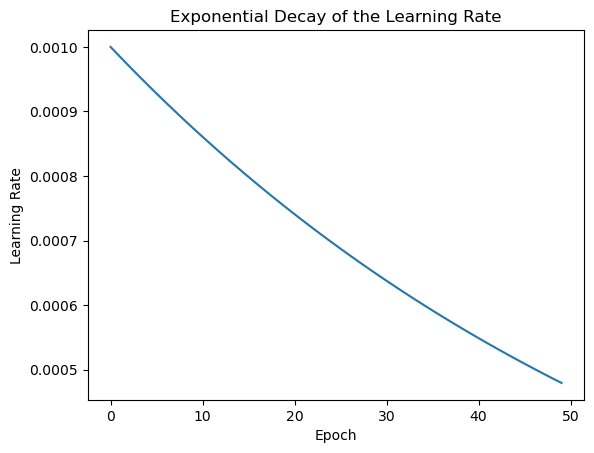

In [6]:


def exponential_decay(epoch,lr_ini=LR,decay_rate=DECAY_RATE,epochs=num_epochs):
    if epoch < epochs*0.001:
        return lr_ini
    else:
        return  lr_ini * np.exp(-decay_rate*epoch)
    
epochs = np.arange(num_epochs)
learning_rates = [exponential_decay(epoch) for epoch in epochs]


plt.plot(epochs, learning_rates, label="Learning Rate")
plt.title("Exponential Decay of the Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(False)
plt.show()  

In [7]:
lr_scheduler = LearningRateScheduler(lambda epoch: exponential_decay(epoch), verbose=1)
optimizer = Adam(learning_rate=LR)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',  min_delta=1e-2, patience=patience, restore_best_weights=True,verbose=1)
save = save_in + '/Results_weights/Best_weights.weights.h5'
checkpoint_cb=tf.keras.callbacks.ModelCheckpoint(save,save_weights_only=True)

In [28]:
# https://g.co/gemini/share/e579fefeb1f5

def encoder(x,filters):
    print(filters)
    x= Conv2D(
            filters=filters,
            kernel_size=(3, 3),
            padding=type_padding,
            use_bias=True)(x)
    x = LeakyReLU(alpha=0.2)(x)
    
    return x

def decoder (x,filter):
    pass

def make_model():
    image_input = Input((img_height, img_width, channel))
    x=layers.Permute((2, 1, 3))(image_input) # sequence w = 256 as temporal axis
    x=layers.Reshape((img_width,img_height,channel,1))(x)
    
    for i in range(6):
        x=encoder(x,number_of_filters[i])
        x = layers.TimeDistributed(x)

    # 3. ConvLSTM para aprender evolución espacio-temporal
    for _ in range(3):
        x = ConvLSTM2D(16, (3, 3), padding=type_padding, return_sequences=True)(x)
    x = ConvLSTM2D(16, (3, 3), padding=type_padding, return_sequences=False)(x)
   
 

In [29]:
make_model()

8


ValueError: Kernel shape must have the same length as input, but received kernel of shape (3, 3, 1, 8) and input of shape (None, 256, 64, 1, 1).

In [ ]:
M=make_model()

In [ ]:
print("Starting trainig")

history = M.fit(train_ds,epochs=num_epochs,validation_data = valid_ds,callbacks=[early_stopping,checkpoint_cb])
callbacks = [lr_scheduler,tf.keras.callbacks.ModelCheckpoint("Unet.keras",save_best_only=True)]
M.save('Completed_Model_fourdecoders.h5')

In [ ]:
results = M.evaluate(test_ds) 
print("Evaluation results:")
for name, value in zip(M.metrics_names, results):
    print(f"{name}: {value:.4f}")

In [ ]:
xtrue=[]
ytrue=[]
for x,y in test_ds:
    xtrue.append(x.numpy())
    ytrue.append(y.numpy())
ypred = list()    
for i in range(len(ytrue)):    
    ypred.append(M.predict(xtrue[i]))

In [ ]:
def plotting():
    N = random.randint(0, len(xtrue)-1)
    M = random.randint(0, nbatch-1)
    titles = [ 'P pred', 'P true','V pred', 'V true','Vx pred', 'Vx true','Vy pred', 'Vy true']
    fig, axes = plt.subplots(4, 3, figsize=(16, 10))
    
    error=[]
    for i in range(4):
            error.append(np.abs(ytrue[M][N][:,:,i]- ypred[M][N][:,:,i]))

            axes[i,0].imshow(ypred[M][N][:,:,i], cmap='gray')
            axes[i, 0].set_title(titles[2*i])
            axes[i, 0].axis('off')

            axes[i,1].imshow(ytrue[M][N][:,:,i], cmap='gray')
            axes[i, 1].set_title(titles[2*i+1])
            axes[i, 1].axis('off')

            e=axes[i,2].imshow(error[0], cmap='turbo')
            axes[i, 2].set_title('Absolute Error')
            axes[i, 2].axis('off')
            plt.colorbar(e, ax=axes[i,2], fraction=0.046)

    for ax in axes.flat:
        ax.axis('off')

In [ ]:
plotting()

In [ ]:
plotting()

In [ ]:
plotting()

In [ ]:
# Recolectar predicciones
y_preds = []
y_trues = []

for x_batch, y_batch in test_ds:
    y_pred = M.predict(x_batch)
    y_preds.append(y_pred)
    y_trues.append(y_batch)

In [ ]:
y_preds = np.concatenate(y_preds, axis=0)  # (N, H, W, 4)
y_trues = np.concatenate(y_trues, axis=0)

In [ ]:
# Calcular MSE y MAE por canal
from sklearn.metrics import mean_squared_error, mean_absolute_error
for i, var in enumerate(["p", "v", "vx", "vy"]):
    mse = mean_squared_error(y_trues[..., i].ravel(), y_preds[..., i].ravel())
    mae = mean_absolute_error(y_trues[..., i].ravel(), y_preds[..., i].ravel())
    print(f"{var}: MSE = {mse:.4f}, MAE = {mae:.4f}")

In [ ]:

pd.DataFrame(history.history)[['loss', 'val_loss']].plot(figsize=(8, 5))
plt.yscale('log')       # Escala logarítmica para el eje Y
plt.grid(True, which='both')  # Mostrar grid tanto en escala mayor como menor
plt.title("Pérdida vs Épocas (Escala Log)")
plt.xlabel("Epochs")
plt.ylabel("Loss (log)")
plt.tight_layout()
plt.show()


In [ ]:

pd.DataFrame(history.history)[['mae', 'val_mae']].plot(figsize=(8, 5))
plt.yscale('log')       # Escala logarítmica para el eje Y
plt.grid(True, which='both')  # Mostrar grid tanto en escala mayor como menor
plt.title("Mae vs Épocas (Escala Log)")
plt.xlabel("Epochs")
plt.ylabel("Mae (log)")
plt.tight_layout()
plt.show()